In [1]:
# Cell 1: Imports and device setup
from pathlib import Path
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import os
import time
from collections import defaultdict

from torchvision import datasets, transforms

try:
    import timm
except ImportError as e:
    raise ImportError('timm is required for this notebook. Install with `pip install timm`.') from e

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

c:\Anaconda\envs\clone_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM: 11.9 GB


In [2]:
# Cell 2: Data loading with 299x299 input (Xception's native resolution per paper)
DATA_ROOT = Path('../data_yolo_faces')
train_dir = DATA_ROOT / 'train'
val_dir = DATA_ROOT / 'val'
test_dir = DATA_ROOT / 'test'

print('CWD        :', Path.cwd())
print('Train path :', train_dir.resolve())
print('Train exists:', train_dir.exists())

# ImageNet normalization (standard for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Paper uses 299x299 input for Xception (its native resolution)
INPUT_SIZE = 299

# Training transforms - paper does not specify augmentation, so we keep it minimal
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),  # 299x299 as per paper
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Evaluation transforms
eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),  # 299x299 as per paper
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transform)
val_dataset = datasets.ImageFolder(root=str(val_dir), transform=eval_transform)
test_dataset = datasets.ImageFolder(root=str(test_dir), transform=eval_transform)

print('Classes:', train_dataset.classes)
print('Train images:', len(train_dataset))
print('Val images  :', len(val_dataset))
print('Test images :', len(test_dataset))

# Paper uses batch_size=32 for XceptionNet
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nBatches per epoch: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}')

CWD        : c:\Users\ASUS\Documents\Deep Learning\notebooks
Train path : C:\Users\ASUS\Documents\Deep Learning\data_yolo_faces\train
Train exists: True
Classes: ['FAKE', 'REAL']
Train images: 97156
Val images  : 20759
Test images : 20784

Batches per epoch: Train=3037, Val=649, Test=650


In [3]:
# Cell 3: Build Xception model following paper specifications
def create_xception(num_classes: int = 2, pretrained: bool = True) -> nn.Module:
    """
    Create XceptionNet as per FF++ paper:
    - Pretrained on ImageNet
    - Replace final FC layer with num_classes outputs
    """
    model = timm.create_model('xception', pretrained=pretrained, num_classes=num_classes)
    return model

# Calculate class weights for imbalanced dataset (paper: "weighing the training images correspondingly")
def compute_class_weights(dataset):
    """Compute inverse-frequency weights as per paper."""
    targets = [label for _, label in dataset.imgs]
    class_counts = np.bincount(targets)
    total = len(targets)
    # Inverse frequency weighting
    weights = total / class_counts
    # Normalize so weights sum to num_classes
    weights = weights / weights.sum() * len(class_counts)
    return torch.tensor(weights, dtype=torch.float32)

# Create model
model = create_xception(num_classes=2, pretrained=True).to(device)

# Compute class weights
class_weights = compute_class_weights(train_dataset).to(device)
print('Class mapping:', train_dataset.class_to_idx)
print('Class weights:', class_weights.cpu().numpy())

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Paper: Adam optimizer with lr=0.0002, β₁=0.9, β₂=0.999, ε=10⁻⁸
LEARNING_RATE = 0.0002  # Paper specification
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE, 
    betas=(0.9, 0.999), 
    eps=1e-8
)

print(f'\nModel: XceptionNet')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Batch size: {BATCH_SIZE}')

c:\Anaconda\envs\clone_gpu\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Class mapping: {'FAKE': 0, 'REAL': 1}
Class weights: [0.28496438 1.7150356 ]

Model: XceptionNet
Parameters: 20,811,050
Learning rate: 0.0002
Batch size: 32


In [4]:
# Cell 4: Training utilities following paper's exact methodology

def freeze_backbone(model):
    """
    Freeze all layers except the final fully connected layer.
    Paper: "fix all weights up to the final layers and pre-train the network for 3 epochs"
    """
    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze final classifier layer
    # In timm's Xception, the classifier is model.fc
    for param in model.fc.parameters():
        param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Frozen backbone: {trainable:,} / {total:,} parameters trainable')

def unfreeze_all(model):
    """
    Unfreeze all layers for full fine-tuning.
    Paper: "After this step, we train the network for 15 more epochs"
    """
    for param in model.parameters():
        param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Unfrozen all layers: {trainable:,} parameters trainable')

def evaluate_accuracy(model, dataloader, device):
    """Compute accuracy on a dataloader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

def train_epoch(model, train_loader, criterion, optimizer, device, val_loader=None, 
                val_checks_per_epoch=10, early_stop_tracker=None):
    """
    Train for one epoch with optional validation checks.
    
    Paper: "We compute validation accuracies ten times per epoch and stop the training 
    process if the validation accuracy does not change for 10 consecutive checks."
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Calculate when to do validation checks
    total_batches = len(train_loader)
    check_interval = max(1, total_batches // val_checks_per_epoch)
    
    val_accuracies = []
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Validation check (10 times per epoch as per paper)
        if val_loader is not None and (batch_idx + 1) % check_interval == 0:
            val_acc = evaluate_accuracy(model, val_loader, device)
            val_accuracies.append(val_acc)
            
            if early_stop_tracker is not None:
                early_stop_tracker.update(val_acc)
            
            model.train()  # Switch back to training mode
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, val_accuracies

class EarlyStopTracker:
    """
    Track validation accuracy for early stopping.
    Paper: "stop the training process if the validation accuracy does not change 
    for 10 consecutive checks"
    """
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_acc = 0.0
        self.counter = 0
        self.best_model_state = None
        
    def update(self, val_acc):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter = 0
            return True  # Improvement
        else:
            self.counter += 1
            return False  # No improvement
    
    def should_stop(self):
        return self.counter >= self.patience
    
    def save_best(self, model):
        self.best_model_state = copy.deepcopy(model.state_dict())
    
    def load_best(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

print('Training utilities defined.')

Training utilities defined.


In [5]:
# Cell 5: STAGE 1 - Freeze backbone, train only final FC layer for 3 epochs
# Paper: "fix all weights up to the final layers and pre-train the network for 3 epochs"

print('=' * 60)
print('STAGE 1: Training with frozen backbone (3 epochs)')
print('Paper: "fix all weights up to the final layers and pre-train the network for 3 epochs"')
print('=' * 60)

# Freeze backbone
freeze_backbone(model)

# Recreate optimizer with only trainable parameters
optimizer_stage1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8
)

STAGE1_EPOCHS = 3
stage1_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(STAGE1_EPOCHS):
    start_time = time.time()
    
    train_loss, train_acc, val_accs = train_epoch(
        model, train_loader, criterion, optimizer_stage1, device,
        val_loader=val_loader, val_checks_per_epoch=10
    )
    
    val_acc = evaluate_accuracy(model, val_loader, device)
    elapsed = time.time() - start_time
    
    stage1_history['train_loss'].append(train_loss)
    stage1_history['train_acc'].append(train_acc)
    stage1_history['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}/{STAGE1_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
          f'Val Acc: {val_acc*100:.2f}% | Time: {elapsed:.1f}s')

print('\nStage 1 completed.')

STAGE 1: Training with frozen backbone (3 epochs)
Paper: "fix all weights up to the final layers and pre-train the network for 3 epochs"
Frozen backbone: 4,098 / 20,811,050 parameters trainable
Epoch 1/3 | Train Loss: 0.6251 | Train Acc: 66.98% | Val Acc: 58.69% | Time: 952.9s
Epoch 2/3 | Train Loss: 0.5920 | Train Acc: 68.84% | Val Acc: 61.03% | Time: 897.8s
Epoch 3/3 | Train Loss: 0.5825 | Train Acc: 69.84% | Val Acc: 75.98% | Time: 891.6s

Stage 1 completed.


In [6]:
# Cell 6: STAGE 2 - Unfreeze all layers, train until convergence with early stopping
# Paper: "After this step, we train the network for 15 more epochs and choose the 
#         best performing model based on validation accuracy"

print('=' * 60)
print('STAGE 2: Full fine-tuning with early stopping')
print('Paper: "train the network for 15 more epochs and choose the best performing model"')
print('=' * 60)

# Unfreeze all layers
unfreeze_all(model)

# Recreate optimizer with all parameters
optimizer_stage2 = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Early stopping tracker (10 consecutive checks without improvement)
early_stopper = EarlyStopTracker(patience=10, min_delta=1e-4)

MAX_EPOCHS_STAGE2 = 15  # Paper mentions 15 more epochs
stage2_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

best_val_acc = 0.0
best_model_state = None

for epoch in range(MAX_EPOCHS_STAGE2):
    start_time = time.time()
    
    train_loss, train_acc, val_accs = train_epoch(
        model, train_loader, criterion, optimizer_stage2, device,
        val_loader=val_loader, val_checks_per_epoch=10,
        early_stop_tracker=early_stopper
    )
    
    val_acc = evaluate_accuracy(model, val_loader, device)
    elapsed = time.time() - start_time
    
    stage2_history['train_loss'].append(train_loss)
    stage2_history['train_acc'].append(train_acc)
    stage2_history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        improved = '✓ New best!'
    else:
        improved = ''
    
    print(f'Epoch {epoch+1}/{MAX_EPOCHS_STAGE2} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
          f'Val Acc: {val_acc*100:.2f}% | Time: {elapsed:.1f}s {improved}')
    
    # Check early stopping
    if early_stopper.should_stop():
        print(f'\nEarly stopping triggered after {epoch+1} epochs '
              f'(no improvement for {early_stopper.patience} consecutive checks)')
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'\nLoaded best model with validation accuracy: {best_val_acc*100:.2f}%')

print('\nStage 2 completed.')

STAGE 2: Full fine-tuning with early stopping
Paper: "train the network for 15 more epochs and choose the best performing model"
Unfrozen all layers: 20,811,050 parameters trainable
Epoch 1/15 | Train Loss: 0.2004 | Train Acc: 91.44% | Val Acc: 90.41% | Time: 1391.5s ✓ New best!
Epoch 2/15 | Train Loss: 0.1081 | Train Acc: 95.10% | Val Acc: 93.25% | Time: 1391.5s ✓ New best!
Epoch 3/15 | Train Loss: 0.0837 | Train Acc: 96.22% | Val Acc: 94.30% | Time: 1375.2s ✓ New best!
Epoch 4/15 | Train Loss: 0.0680 | Train Acc: 96.82% | Val Acc: 93.17% | Time: 1379.3s 

Early stopping triggered after 4 epochs (no improvement for 10 consecutive checks)

Loaded best model with validation accuracy: 94.30%

Stage 2 completed.


In [8]:
# Cell 7: Final evaluation on test set
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print('=' * 60)
print('FINAL EVALUATION ON TEST SET')
print('=' * 60)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Test accuracy
test_acc = (all_preds == all_labels).mean()
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print('\nConfusion Matrix:')
print(cm)

# Classification report
class_names = test_dataset.classes
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

FINAL EVALUATION ON TEST SET

Test Accuracy: 93.58%

Confusion Matrix:
[[16928   896]
 [  439  2521]]

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9747    0.9497    0.9621     17824
        REAL     0.7378    0.8517    0.7907      2960

    accuracy                         0.9358     20784
   macro avg     0.8563    0.9007    0.8764     20784
weighted avg     0.9410    0.9358    0.9377     20784



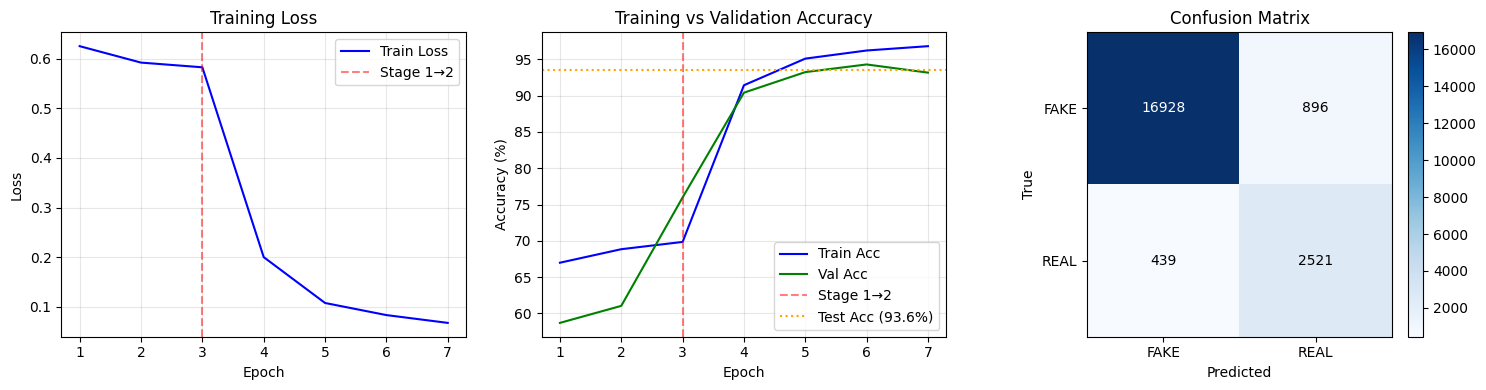


Figure saved to models/xception_paper_replication_results.png


In [9]:
# Cell 8: Plot training curves and confusion matrix (matplotlib only)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Combine stage 1 and stage 2 history
all_train_loss = stage1_history['train_loss'] + stage2_history['train_loss']
all_train_acc = stage1_history['train_acc'] + stage2_history['train_acc']
all_val_acc = stage1_history['val_acc'] + stage2_history['val_acc']
epochs = list(range(1, len(all_train_loss) + 1))

# Add vertical line to show stage boundary
stage1_end = STAGE1_EPOCHS

# Plot 1: Training Loss
axes[0].plot(epochs, all_train_loss, 'b-', label='Train Loss')
axes[0].axvline(x=stage1_end, color='r', linestyle='--', alpha=0.5, label='Stage 1→2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[1].plot(epochs, [a*100 for a in all_train_acc], 'b-', label='Train Acc')
axes[1].plot(epochs, [a*100 for a in all_val_acc], 'g-', label='Val Acc')
axes[1].axvline(x=stage1_end, color='r', linestyle='--', alpha=0.5, label='Stage 1→2')
axes[1].axhline(y=test_acc*100, color='orange', linestyle=':', label=f'Test Acc ({test_acc*100:.1f}%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrix (using matplotlib imshow instead of seaborn)
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].figure.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set(xticks=np.arange(cm.shape[1]),
            yticks=np.arange(cm.shape[0]),
            xticklabels=class_names,
            yticklabels=class_names,
            xlabel='Predicted',
            ylabel='True',
            title='Confusion Matrix')

# Add text annotations to confusion matrix
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('../models/xception_paper_replication_results.png', dpi=150)
plt.show()

print('\nFigure saved to models/xception_paper_replication_results.png')

In [10]:
# Cell 9: Save model
save_path = '../models/xception_paper_replication.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer_stage2.state_dict(),
    'test_accuracy': test_acc,
    'best_val_accuracy': best_val_acc,
    'stage1_history': stage1_history,
    'stage2_history': stage2_history,
    'class_names': class_names,
    'confusion_matrix': cm,
    'training_config': {
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'stage1_epochs': STAGE1_EPOCHS,
        'max_stage2_epochs': MAX_EPOCHS_STAGE2,
        'optimizer': 'Adam',
        'optimizer_params': {'betas': (0.9, 0.999), 'eps': 1e-8}
    }
}, save_path)

print(f'Model saved to {save_path}')

Model saved to ../models/xception_paper_replication.pth


In [11]:
# Cell 10: Summary comparison with paper results
print('=' * 70)
print('SUMMARY: Comparison with FaceForensics++ Paper Results')
print('=' * 70)
print()
print('Paper Results (XceptionNet on c23 compression):')
print('  - Binary detection accuracy: 95.73%')
print('  - Dataset: 720 train / 140 val / 140 test videos')
print('  - Face extraction: Face tracking with 1.3× enlargement factor')
print('  - Manipulation methods: DeepFakes, Face2Face, FaceSwap, NeuralTextures')
print()
print('Our Replication Results:')
print(f'  - Binary detection accuracy: {test_acc*100:.2f}%')
print(f'  - Best validation accuracy: {best_val_acc*100:.2f}%')
print(f'  - Train images: {len(train_dataset):,}')
print(f'  - Val images: {len(val_dataset):,}')
print(f'  - Test images: {len(test_dataset):,}')
print(f'  - Face extraction: YOLO-based cropping')
print(f'  - Manipulation methods: {"Includes FaceShifter, DeepFakeDetection (6 total)"}')
print()
print('Training Configuration (matching paper):')
print(f'  - Input size: {INPUT_SIZE}×{INPUT_SIZE} (paper: 299×299) ✓')
print(f'  - Batch size: {BATCH_SIZE} (paper: 32) ✓')
print(f'  - Learning rate: {LEARNING_RATE} (paper: 0.0002) ✓')
print(f'  - Optimizer: Adam (β₁=0.9, β₂=0.999, ε=10⁻⁸) ✓')
print(f'  - Stage 1: Frozen backbone for {STAGE1_EPOCHS} epochs (paper: 3) ✓')
print(f'  - Stage 2: Full fine-tuning up to {MAX_EPOCHS_STAGE2} epochs (paper: 15) ✓')
print(f'  - Early stopping: 10 consecutive val checks without improvement ✓')
print(f'  - Class weighting: Inverse frequency ✓')
print()
print('Differences from paper:')
print('  - Face extraction method (YOLO vs Face2Face tracking)')
print('  - Additional manipulation methods in dataset')
print('  - Different source videos')

SUMMARY: Comparison with FaceForensics++ Paper Results

Paper Results (XceptionNet on c23 compression):
  - Binary detection accuracy: 95.73%
  - Dataset: 720 train / 140 val / 140 test videos
  - Face extraction: Face tracking with 1.3× enlargement factor
  - Manipulation methods: DeepFakes, Face2Face, FaceSwap, NeuralTextures

Our Replication Results:
  - Binary detection accuracy: 93.58%
  - Best validation accuracy: 94.30%
  - Train images: 97,156
  - Val images: 20,759
  - Test images: 20,784
  - Face extraction: YOLO-based cropping
  - Manipulation methods: Includes FaceShifter, DeepFakeDetection (6 total)

Training Configuration (matching paper):
  - Input size: 299×299 (paper: 299×299) ✓
  - Batch size: 32 (paper: 32) ✓
  - Learning rate: 0.0002 (paper: 0.0002) ✓
  - Optimizer: Adam (β₁=0.9, β₂=0.999, ε=10⁻⁸) ✓
  - Stage 1: Frozen backbone for 3 epochs (paper: 3) ✓
  - Stage 2: Full fine-tuning up to 15 epochs (paper: 15) ✓
  - Early stopping: 10 consecutive val checks without 